In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy 

In [7]:
import sys
print(sys.executable)


C:\Users\Susmarika Koirala\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe


In [8]:
df=pd.read_csv("intents_dataset.csv")
df

,intent,question
0,Set Alarm,Set an alarm for 7 AM tomorrow
1,Set Alarm,Can you set an alarm for 6:30 in the morning?
2,Set Alarm,Wake me up at 8 AM
3,Set Alarm,Set alarm for 9 PM tonight
4,Set Alarm,Create an alarm for 5:30 AM
...,...,...
226,Find Contact,Find emergency contacts
227,Find Contact,Show mom's contact details
228,Find Contact,Find business contacts
229,Find Contact,Contact details for plumber


In [9]:
print(df.shape)
print(df['intent'].nunique())
df['intent'].value_counts().head(10)

(231, 2)
24


intent
Set Alarm        10
Send Message     10
Make Call        10
Check Weather    10
Set Reminder     10
Play Music       10
Search Web       10
Calculate        10
Navigate         10
Set Timer        10
Name: count, dtype: int64

In [ ]:
# import pandas as pd
# import spacy
# from sklearn.model_selection import train_test_split
# from sklearn.svm import SVC
# from sklearn.preprocessing import LabelEncoder
# from sklearn.metrics import classification_report
# import pickle

# # Load model and data
# nlp = spacy.load("en_core_web_lg")
# df = pd.read_csv("intents_dataset.csv")

# # Clean data
# df = df.dropna(subset=['intent', 'question'])
# df['question'] = df['question'].astype(str)

# # Encode labels
# le = LabelEncoder()
# y = le.fit_transform(df['intent'])

# # Convert text → vectors
# X = [nlp(text).vector for text in df['question']]

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Train SVM
# model = SVC(kernel='linear')
# model.fit(X_train, y_train)

# # Evaluate
# y_pred = model.predict(X_test)
# print(classification_report(y_test, y_pred))

# # Save model
# pickle.dump(model, open('svc_model.pkl', 'wb'))
# pickle.dump(le, open('label_encoder.pkl', 'wb'))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1
           2       1.00      1.00      1.00         2
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       0.50      1.00      0.67         1
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00         2
          10       0.75      0.75      0.75         4
          11       0.00      0.00      0.00         1
          12       1.00      1.00      1.00         2
          14       0.50      1.00      0.67         1
          15       1.00      0.50      0.67         2
          16       0.00      0.00      0.00         1
          17       0.50      0.50      0.50         4
          18       1.00    

C:\Users\Susmarika Koirala\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Susmarika Koirala\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Susmarika Koirala\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311

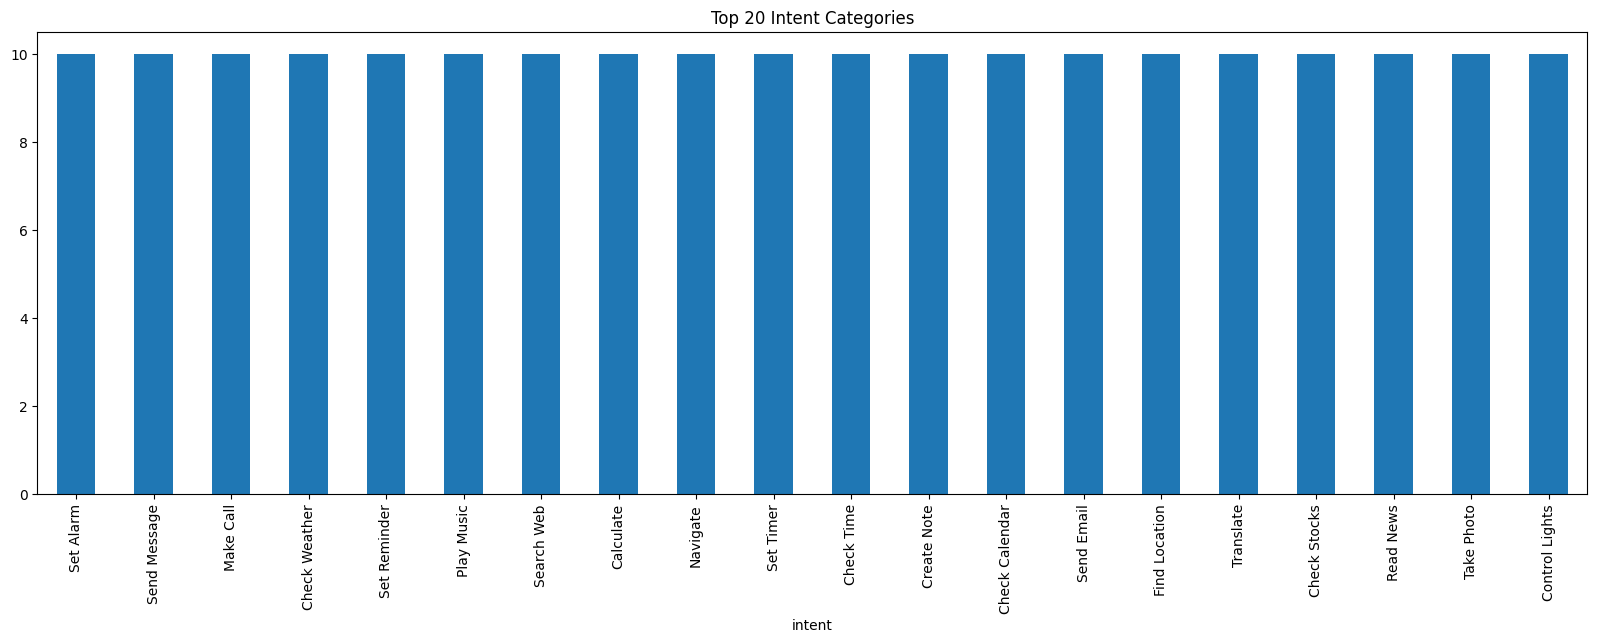

In [6]:
df['intent'].value_counts().head(20).plot(kind='bar', figsize=(20,6))
plt.title("Top 20 Intent Categories")
plt.show()

In [7]:
nlp=spacy.load('en_core_web_lg')

In [8]:
def get_vector(text):
    doc = nlp(text)
    return doc.vector

In [9]:
X = np.array([get_vector(text) for text in df['question']])
y = df['intent']

In [10]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y_encoded=le.fit_transform(y)

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
import pandas as pd
import spacy
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import pickle

df = pd.read_csv("intents_dataset.csv")
df = df.dropna(subset=['intent', 'question'])
df['question'] = df['question'].astype(str)

le = LabelEncoder()
y = le.fit_transform(df['intent'])

print("Loading spaCy model...")
nlp = spacy.load("en_core_web_lg")

print("Converting text to embeddings...")
X = np.array([nlp(text).vector for text in df['question']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training SVM classifier...")
# Use class_weight='balanced' to handle class imbalance
model = SVC(kernel='linear', probability=True, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy*100:.2f}%\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

pickle.dump(model, open("svc_model.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))
print("\nModel and label encoder saved!")

def predict_intent(query):
    vec = nlp(query).vector.reshape(1, -1)
    pred_class = model.predict(vec)[0]
    pred_proba = model.predict_proba(vec).max()
    intent_label = le.inverse_transform([pred_class])[0]
    return intent_label, pred_proba

print("\n--- Testing Predictions ---")
test_queries = [
    "Set an alarm for 7 AM tomorrow",
    "Play some music",
    "Send a message to John",
    "What's the weather today?",
    "Turn on the flashlight",
]

for q in test_queries:
    intent, conf = predict_intent(q)
    print(f"Query: '{q}' → Predicted Intent: '{intent}' (Confidence: {conf:.2f})")


Loading spaCy model...
Converting text to embeddings...
Training SVM classifier...

Accuracy: 89.02%

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         2
           3       0.67      1.00      0.80         4
           4       1.00      0.75      0.86         4
           5       0.75      0.75      0.75         4
           6       1.00      0.75      0.86         4
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         4
           9       0.75      1.00      0.86         3
          10       1.00      1.00      1.00         4
          11       1.00      0.75      0.86         4
          12       0.80      1.00      0.89         4
          13       1.00      1.00      1.00         4
          14       1.00      0.75      0.86         4
         